# Categorização de corredores — KMeans

Comparamos três formas de clusterizar atletas (k=3), cada uma com **duas features** agregadas por atleta:

1. **Distância + pace** — perfil de corrida (volume por treino e velocidade)
2. **FC + distância** — intensidade cardiovascular vs distância percorrida
3. **Distância + frequência semanal** — volume por treino vs regularidade de treinos


In [137]:
%matplotlib inline

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from dataset.analise import carregar_dataset
from dataset.categorizar.kmeans import treina_kmeans, treina_kmeans_por_genero
from dataset.categorizar.tabela_fichas import tabela_fichas
from dataset.categorizar import visualizacao_fichas
from dataset.categorizar.visualizacao_fichas import (
    montar_fichas_atletas,
    plotar_ficha_atleta,
    plotar_fichas_atletas,
)
importlib.reload(visualizacao_fichas)
from dataset.constants import (
    COL_ATHLETE,
    COL_CLUSTER_CORREDOR,
    COL_DISTANCE,
    COL_FREQUENCIA,
    COL_GENDER,
    COL_HR,
    COL_N_CORRIDAS,
    COL_PACE,
)
from dataset.preprocessamento import formatar_delta_pace, formatar_pace, preprocessar


In [138]:
df_raw = carregar_dataset(root / "dataset/raw-data-kaggle.csv")
df = preprocessar(df_raw)

print(f"Corridas: {df.height} | Atletas: {df[COL_ATHLETE].n_unique()}")


Corridas: 40534 | Atletas: 114


## Comparação das combinações de features

Testamos **três pares de variáveis** com KMeans (k=3) para decidir qual combinação usar na categorização final:

| # | Combinação | O que separa |
|---|------------|--------------|
| 1 | Distância + pace | Perfil de corrida (volume por treino × velocidade) |
| 2 | FC + distância | Intensidade cardiovascular × distância |
| 3 | Distância + frequência | Volume por treino × regularidade semanal |

Critérios para escolher: **silhouette**, equilíbrio entre clusters e **interpretabilidade** do perfil de corredor.



1. Distância + pace
Features: ['distance (m)', 'pace_min_km']
Inércia: 101.9085
Silhouette: 0.3805
Atletas clusterizados: 114
Contagem por cluster:
shape: (3, 2)
┌──────────────────┬─────────┐
│ cluster_corredor ┆ atletas │
│ ---              ┆ ---     │
│ i32              ┆ u32     │
╞══════════════════╪═════════╡
│ 0                ┆ 24      │
│ 1                ┆ 68      │
│ 2                ┆ 22      │
└──────────────────┴─────────┘
Centros (escala original):
  cluster_0: dist=7.64 km | pace=6:41/km
  cluster_1: dist=10.88 km | pace=5:36/km
  cluster_2: dist=7.98 km | pace=5:14/km


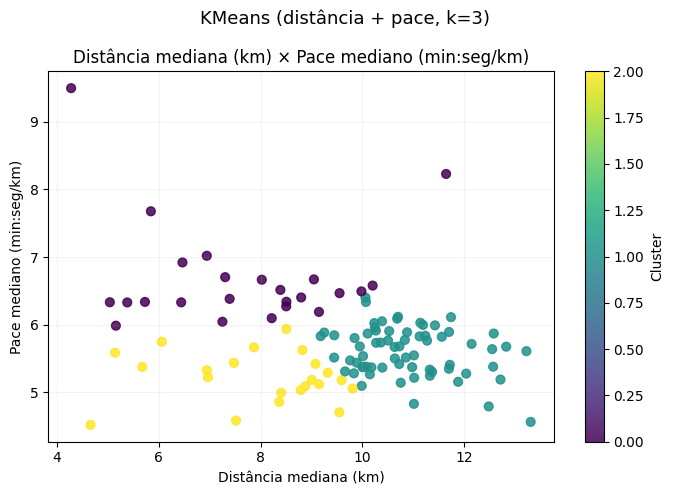


2. FC + distância
Features: ['average heart rate (bpm)', 'distance (m)']
Inércia: 99.718
Silhouette: 0.4758
Atletas clusterizados: 114
Contagem por cluster:
shape: (3, 2)
┌──────────────────┬─────────┐
│ cluster_corredor ┆ atletas │
│ ---              ┆ ---     │
│ i32              ┆ u32     │
╞══════════════════╪═════════╡
│ 0                ┆ 25      │
│ 1                ┆ 78      │
│ 2                ┆ 11      │
└──────────────────┴─────────┘
Centros (escala original):
  cluster_0: fc=148.9 bpm | dist=6.77 km
  cluster_1: fc=147.4 bpm | dist=10.58 km
  cluster_2: fc=162.7 bpm | dist=9.46 km


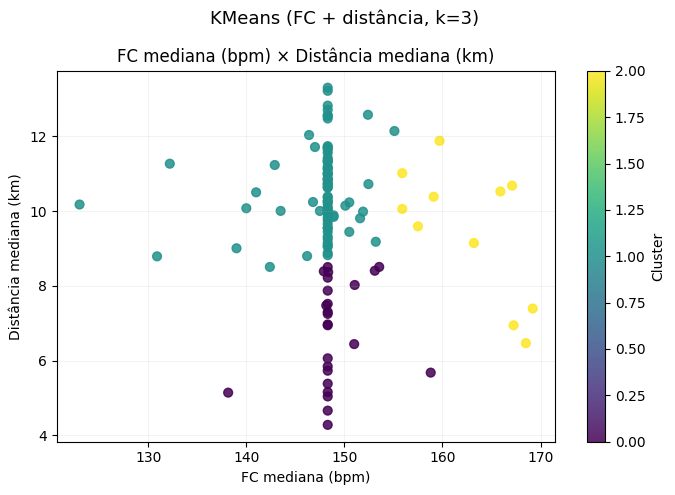


3. Distância + frequência semanal
Features: ['distance (m)', 'frequencia_semana']
Inércia: 81.2448
Silhouette: 0.4509
Atletas clusterizados: 114
Contagem por cluster:
shape: (3, 2)
┌──────────────────┬─────────┐
│ cluster_corredor ┆ atletas │
│ ---              ┆ ---     │
│ i32              ┆ u32     │
╞══════════════════╪═════════╡
│ 0                ┆ 14      │
│ 1                ┆ 76      │
│ 2                ┆ 24      │
└──────────────────┴─────────┘
Centros (escala original):
  cluster_0: dist=10.71 km | freq=4.29 corridas/semana
  cluster_1: dist=10.39 km | freq=1.93 corridas/semana
  cluster_2: dist=6.61 km | freq=1.03 corridas/semana


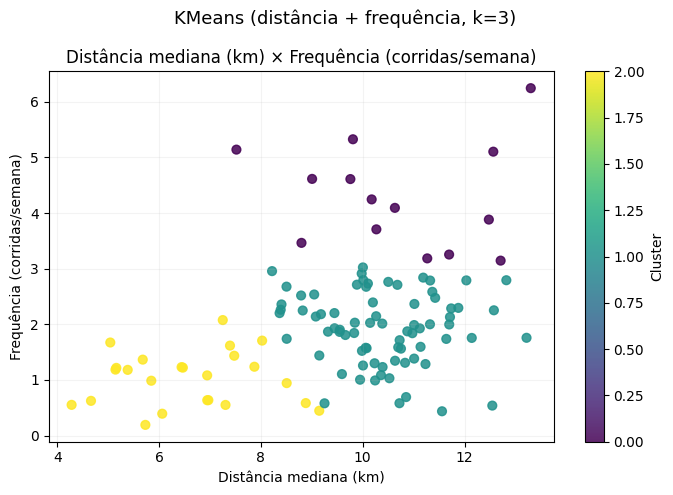

In [139]:
COMBINACOES = {
    "distancia_pace": {
        "titulo": "1. Distância + pace",
        "features": [COL_DISTANCE, COL_PACE],
    },
    "fc_distancia": {
        "titulo": "2. FC + distância",
        "features": [COL_HR, COL_DISTANCE],
    },
    "distancia_frequencia": {
        "titulo": "3. Distância + frequência semanal",
        "features": [COL_DISTANCE, COL_FREQUENCIA],
    },
}

resultados = {}
for chave, cfg in COMBINACOES.items():
    print(f"\n{'=' * 60}")
    print(cfg["titulo"])
    print('=' * 60)
    resultados[chave] = treina_kmeans(
        df,
        features=cfg["features"],
        n_clusters=3,
        plotar=True,
        verbose=True,
    )


In [140]:
LABELS_EXIBIR = {
    COL_DISTANCE: "distancia_km",
    COL_PACE: "pace",
    COL_HR: "fc_bpm",
    COL_FREQUENCIA: "freq_semana",
}

resumo_comparativo = []
centros_por_combinacao = []

for chave, cfg in COMBINACOES.items():
    r = resultados[chave]
    contagem = r.detalhes["contagem_clusters"]
    atletas_por_cluster = [c["atletas"] for c in contagem]
    resumo_comparativo.append({
        "combinacao": cfg["titulo"],
        "silhouette": round(r.metricas["silhouette"], 4),
        "inercia": round(r.metricas["inercia"], 4),
        "atletas": r.df_exibir.height,
        "min_cluster": min(atletas_por_cluster),
        "max_cluster": max(atletas_por_cluster),
    })

    for nome, centro in r.detalhes["centros"].items():
        linha = {"combinacao": cfg["titulo"], "cluster": nome}
        for col in cfg["features"]:
            valor = centro[col]
            if col == COL_DISTANCE:
                linha[LABELS_EXIBIR[col]] = round(valor / 1000, 2)
            elif col == COL_PACE:
                linha[LABELS_EXIBIR[col]] = formatar_pace(valor)
            else:
                linha[LABELS_EXIBIR[col]] = round(valor, 2)
        centros_por_combinacao.append(linha)

df_resumo = pl.DataFrame(resumo_comparativo).sort("silhouette", descending=True)
print("Resumo comparativo (k=3) — ordenado por silhouette:")
display(df_resumo)
print("\nCentros por combinação (pace em min:seg/km):")
display(pl.DataFrame(centros_por_combinacao))


Resumo comparativo (k=3) — ordenado por silhouette:


combinacao,silhouette,inercia,atletas,min_cluster,max_cluster
str,f64,f64,i64,i64,i64
"""2. FC + distância""",0.4758,99.718,114,11,78
"""3. Distância + frequência sema…",0.4509,81.2448,114,14,76
"""1. Distância + pace""",0.3805,101.9085,114,22,68



Centros por combinação (pace em min:seg/km):


combinacao,cluster,distancia_km,pace,fc_bpm,freq_semana
str,str,f64,str,f64,f64
"""1. Distância + pace""","""cluster_0""",7.64,"""6:41/km""",null,null
"""1. Distância + pace""","""cluster_1""",10.88,"""5:36/km""",null,null
"""1. Distância + pace""","""cluster_2""",7.98,"""5:14/km""",null,null
"""2. FC + distância""","""cluster_0""",6.77,null,148.91,null
"""2. FC + distância""","""cluster_1""",10.58,null,147.36,null
"""2. FC + distância""","""cluster_2""",9.46,null,162.66,null
"""3. Distância + frequência sema…","""cluster_0""",10.71,null,null,4.29
"""3. Distância + frequência sema…","""cluster_1""",10.39,null,null,1.93
"""3. Distância + frequência sema…","""cluster_2""",6.61,null,null,1.03


## Combinação escolhida

**Recomendação: Distância + pace** (`distancia_pace`).

Na **comparação inicial**, testamos k=3 **sem** separar gênero (3 clusters no total).

Na **análise detalhada**, adicionamos a coluna **`gender`** e clusterizamos
**homens e mulheres separadamente** — após escolher k por silhouette (próxima seção),
usamos **k=2 para cada gênero → 4 categorias** (`C0-M`, `C1-M`, `C0-F`, `C1-F`).

> Pace exibido em **min:seg/km** (ex.: 6:40/km).

In [141]:
COMBINACAO_ESCOLHIDA = "distancia_pace"
K_POR_GENERO = 2

cfg = COMBINACOES[COMBINACAO_ESCOLHIDA]

print("Comparação inicial (referência, sem separar gênero):")
ref = resultados[COMBINACAO_ESCOLHIDA]
print(f"  Silhouette: {ref.metricas['silhouette']:.4f} | clusters: 3")


Comparação inicial (referência, sem separar gênero):
  Silhouette: 0.3805 | clusters: 3


## Escolha de k (por gênero)

Antes de clusterizar, testamos **k de 2 a 7** com curva de silhouette **separadamente** em masculino e feminino — para justificar **k=2** (4 categorias finais).


Silhouette por k — clusterização separada por gênero:


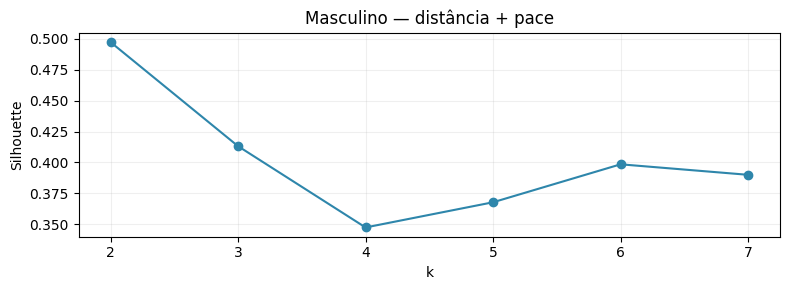

k,silhouette
i64,f64
2,0.497374
3,0.413197
4,0.347455
5,0.367833
6,0.398527
7,0.39003


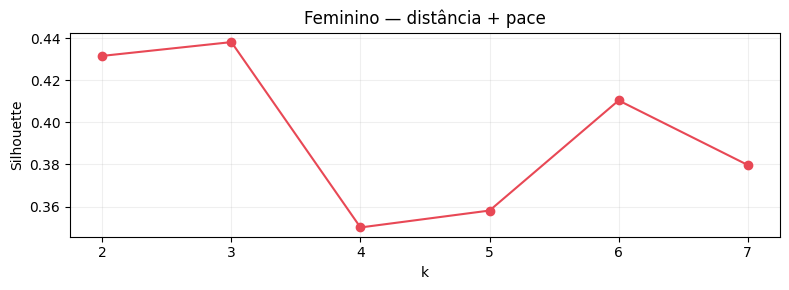

k,silhouette
i64,f64
2,0.431607
3,0.43816
4,0.350072
5,0.358109
6,0.410437
7,0.379756


In [142]:
ks = range(2, 8)

print("Silhouette por k — clusterização separada por gênero:")
for genero in ["M", "F"]:
    sils = []
    rotulo = "Masculino" if genero == "M" else "Feminino"
    df_genero = df.filter(pl.col(COL_GENDER).str.to_uppercase() == genero)
    for k in ks:
        r = treina_kmeans(df_genero, features=cfg["features"], n_clusters=k, plotar=False, verbose=False)
        sils.append(r.metricas["silhouette"])
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(list(ks), sils, marker="o", color="#2E86AB" if genero == "M" else "#E84855")
    ax.set_title(f"{rotulo} — distância + pace")
    ax.set_xlabel("k")
    ax.set_ylabel("Silhouette")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
    display(pl.DataFrame({"k": list(ks), "silhouette": sils}))


In [ ]:
print(f"\nAnálise detalhada — {cfg['titulo']} + gênero (4 categorias):")
resultado = treina_kmeans_por_genero(
    df,
    features=cfg["features"],
    n_clusters=K_POR_GENERO,
    plotar=True,
    verbose=True,
)
perfil = resultado.df_exibir


## Análise detalhada — distância + pace **com gênero**

Homens e mulheres são clusterizados **em separado** (k=2 cada) → **4 categorias**.
Rankings de pace comparam atletas do mesmo gênero e cluster.

Colunas usadas: `distance (m)`, `pace_min_km` e **`gender`**.


In [143]:
resumo_categoria = (
    perfil.group_by("categoria", COL_GENDER)
    .agg(
        pl.len().alias("atletas"),
        (pl.col(COL_DISTANCE).median() / 1000).round(2).alias("dist_km_med"),
        pl.col(COL_PACE).median().alias("_pace_med"),
        pl.col(COL_FREQUENCIA).median().round(2).alias("freq_semana_med"),
    )
    .sort("categoria")
    .with_columns(
        pl.col("_pace_med").map_elements(formatar_pace, return_dtype=pl.Utf8).alias("pace_med"),
    )
    .drop("_pace_med")
)

print(f"Total de categorias: {perfil['categoria'].n_unique()}")
resumo_categoria


Total de categorias: 4


categoria,gender,atletas,dist_km_med,freq_semana_med,pace_med
str,str,u32,f64,f64,str
"""C0-F""","""F""",18,10.08,1.97,"""5:55/km"""
"""C0-M""","""M""",16,6.96,1.2,"""5:52/km"""
"""C1-F""","""F""",12,7.1,1.42,"""6:31/km"""
"""C1-M""","""M""",68,10.66,2.08,"""5:24/km"""


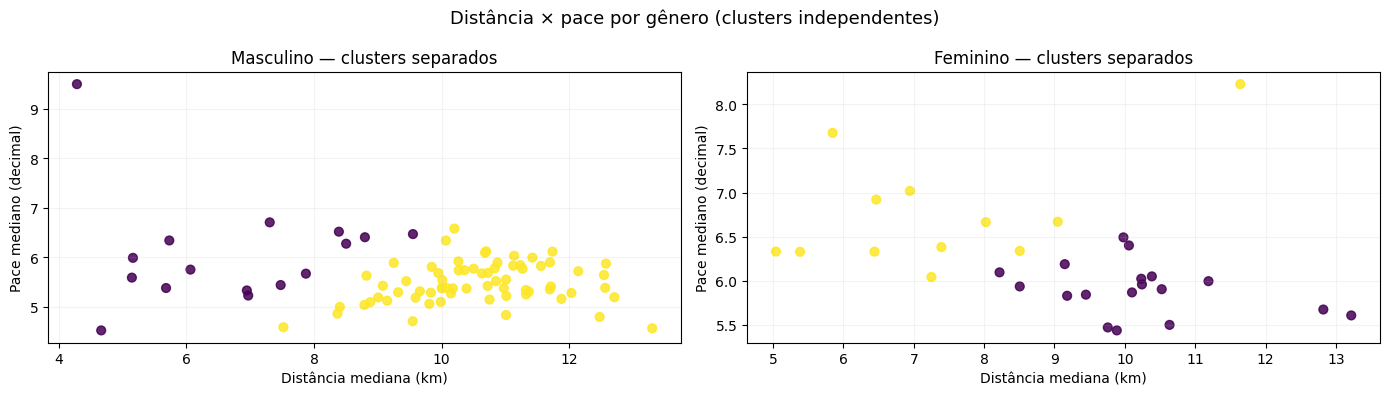

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, genero in zip(axes, ["M", "F"]):
    sub = perfil.filter(pl.col(COL_GENDER) == genero)
    titulo = "Masculino" if genero == "M" else "Feminino"
    ax.scatter(
        (sub[COL_DISTANCE] / 1000).to_numpy(),
        sub[COL_PACE].to_numpy(),
        c=sub[COL_CLUSTER_CORREDOR].to_numpy(),
        cmap="viridis",
        alpha=0.85,
        s=40,
    )
    ax.set_xlabel("Distância mediana (km)")
    ax.set_ylabel("Pace mediano (decimal)")
    ax.set_title(f"{titulo} — clusters separados")
    ax.grid(alpha=0.15)

fig.suptitle("Distância × pace por gênero (clusters independentes)", fontsize=13)
plt.tight_layout()
plt.show()


## Categorias geradas (cluster × gênero)

Cada categoria é um cluster KMeans **dentro de um gênero**.
Mulheres e homens **não competem no mesmo ranking** de pace.


In [145]:
display(resumo_categoria)

print("\nMétricas por gênero:")
for genero, m in resultado.detalhes["metricas_por_genero"].items():
    rotulo = "Masculino" if genero == "M" else "Feminino"
    print(
        f"  {rotulo}: {m['n_atletas']} atletas | k={m['k']} | "
        f"silhouette={m['silhouette']:.4f}"
    )


categoria,gender,atletas,dist_km_med,freq_semana_med,pace_med
str,str,u32,f64,f64,str
"""C0-F""","""F""",18,10.08,1.97,"""5:55/km"""
"""C0-M""","""M""",16,6.96,1.2,"""5:52/km"""
"""C1-F""","""F""",12,7.1,1.42,"""6:31/km"""
"""C1-M""","""M""",68,10.66,2.08,"""5:24/km"""



Métricas por gênero:
  Masculino: 84 atletas | k=2 | silhouette=0.4974
  Feminino: 30 atletas | k=2 | silhouette=0.4316


## Atletas por categoria — posição no pace

Para cada categoria (`C0-M`, `C1-F`, …), calculamos melhor/pior pace e o ranking
do atleta **dentro do mesmo gênero e cluster**.


In [127]:
fichas = montar_fichas_atletas(perfil)

print(f"Fichas: {fichas.height} atletas | {fichas['categoria'].n_unique()} categorias")
tabela_fichas(fichas)


Fichas: 114 atletas | 4 categorias


id,nome,genero,categoria,corridas,cluster,dist_km,pace,melhor_categoria,pior_categoria,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,str,u32,i32,f64,str,str,str,str,str,u32,u32
5035018,"""Júlia Almeida""","""F""","""C0-F""",836,0,9.89,"""5:26/km""","""5:26/km""","""6:30/km""","""+0s""","""+1:03""",1,18
20181492,"""Melissa Rocha""","""F""","""C0-F""",676,0,9.76,"""5:28/km""","""5:26/km""","""6:30/km""","""+2s""","""+1:01""",2,18
19905281,"""Nicole Barbosa""","""F""","""C0-F""",169,0,10.64,"""5:30/km""","""5:26/km""","""6:30/km""","""+4s""","""+59s""",3,18
20032449,"""Tânia Queiroz""","""F""","""C0-F""",264,0,13.22,"""5:36/km""","""5:26/km""","""6:30/km""","""+10s""","""+53s""",4,18
18845906,"""Sofia Castro""","""F""","""C0-F""",431,0,12.82,"""5:40/km""","""5:26/km""","""6:30/km""","""+14s""","""+49s""",5,18
…,…,…,…,…,…,…,…,…,…,…,…,…,…
10825360,"""Thiago Rocha""","""M""","""C1-M""",785,1,10.68,"""6:05/km""","""4:34/km""","""6:35/km""","""+1:32""","""+29s""",64,68
5688059,"""Felipe Souza""","""M""","""C1-M""",722,1,11.74,"""6:07/km""","""4:34/km""","""6:35/km""","""+1:33""","""+28s""",65,68
5492554,"""Gustavo Lima""","""M""","""C1-M""",186,1,10.7,"""6:07/km""","""4:34/km""","""6:35/km""","""+1:33""","""+28s""",66,68


In [146]:
for categoria in sorted(fichas["categoria"].unique().to_list()):
    subset = fichas.filter(pl.col("categoria") == categoria)
    melhor = formatar_pace(subset["pace_melhor_categoria"][0])
    pior = formatar_pace(subset["pace_pior_categoria"][0])
    print(f"\n{categoria} — melhor: {melhor} | pior: {pior} | atletas: {subset.height}")
    display(tabela_fichas(subset).head(5))



C0-F — melhor: 5:26/km | pior: 6:30/km | atletas: 18


id,nome,genero,categoria,corridas,cluster,dist_km,pace,melhor_categoria,pior_categoria,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,str,u32,i32,f64,str,str,str,str,str,u32,u32
5035018,"""Júlia Almeida""","""F""","""C0-F""",836,0,9.89,"""5:26/km""","""5:26/km""","""6:30/km""","""+0s""","""+1:03""",1,18
20181492,"""Melissa Rocha""","""F""","""C0-F""",676,0,9.76,"""5:28/km""","""5:26/km""","""6:30/km""","""+2s""","""+1:01""",2,18
19905281,"""Nicole Barbosa""","""F""","""C0-F""",169,0,10.64,"""5:30/km""","""5:26/km""","""6:30/km""","""+4s""","""+59s""",3,18
20032449,"""Tânia Queiroz""","""F""","""C0-F""",264,0,13.22,"""5:36/km""","""5:26/km""","""6:30/km""","""+10s""","""+53s""",4,18
18845906,"""Sofia Castro""","""F""","""C0-F""",431,0,12.82,"""5:40/km""","""5:26/km""","""6:30/km""","""+14s""","""+49s""",5,18



C0-M — melhor: 4:31/km | pior: 9:30/km | atletas: 16


id,nome,genero,categoria,corridas,cluster,dist_km,pace,melhor_categoria,pior_categoria,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,str,u32,i32,f64,str,str,str,str,str,u32,u32
26363316,"""Kaique Beltrão""","""M""","""C0-M""",64,0,4.66,"""4:31/km""","""4:31/km""","""9:30/km""","""+0s""","""+4:59""",1,16
30414122,"""Hélio Crispim""","""M""","""C0-M""",43,0,6.97,"""5:13/km""","""4:31/km""","""9:30/km""","""+42s""","""+4:16""",2,16
6583234,"""Samuel Borges""","""M""","""C0-M""",664,0,6.95,"""5:20/km""","""4:31/km""","""9:30/km""","""+48s""","""+4:10""",3,16
38870390,"""Henrique Pinto""","""M""","""C0-M""",8,0,5.68,"""5:23/km""","""4:31/km""","""9:30/km""","""+51s""","""+4:07""",4,16
32507764,"""Vicente Amorim""","""M""","""C0-M""",112,0,7.48,"""5:26/km""","""4:31/km""","""9:30/km""","""+55s""","""+4:04""",5,16



C1-F — melhor: 6:03/km | pior: 8:14/km | atletas: 12


id,nome,genero,categoria,corridas,cluster,dist_km,pace,melhor_categoria,pior_categoria,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,str,u32,i32,f64,str,str,str,str,str,u32,u32
25277048,"""Ingrid Siqueira""","""F""","""C1-F""",246,1,7.25,"""6:03/km""","""6:03/km""","""8:14/km""","""+0s""","""+2:11""",1,12
20557028,"""Lívia Brandão""","""F""","""C1-F""",169,1,5.38,"""6:20/km""","""6:03/km""","""8:14/km""","""+17s""","""+1:54""",2,12
15002603,"""Queila Moura""","""F""","""C1-F""",235,1,6.44,"""6:20/km""","""6:03/km""","""8:14/km""","""+17s""","""+1:54""",3,12
37580157,"""Clara Martins""","""F""","""C1-F""",88,1,5.04,"""6:20/km""","""6:03/km""","""8:14/km""","""+17s""","""+1:54""",4,12
10305317,"""Sabrina Lima""","""F""","""C1-F""",218,1,8.51,"""6:20/km""","""6:03/km""","""8:14/km""","""+18s""","""+1:53""",5,12



C1-M — melhor: 4:34/km | pior: 6:35/km | atletas: 68


id,nome,genero,categoria,corridas,cluster,dist_km,pace,melhor_categoria,pior_categoria,delta_melhor,delta_pior,rank,n_categoria
i64,str,str,str,u32,i32,f64,str,str,str,str,str,u32,u32
13435425,"""Gilberto Pacheco""","""M""","""C1-M""",1210,1,13.3,"""4:34/km""","""4:34/km""","""6:35/km""","""+0s""","""+2:01""",1,68
27655563,"""Patrick Neves""","""M""","""C1-M""",592,1,7.52,"""4:35/km""","""4:34/km""","""6:35/km""","""+1s""","""+2:00""",2,68
8180382,"""Orlando Pires""","""M""","""C1-M""",480,1,9.55,"""4:42/km""","""4:34/km""","""6:35/km""","""+8s""","""+1:52""",3,68
7947798,"""Vitor Antunes""","""M""","""C1-M""",982,1,12.48,"""4:48/km""","""4:34/km""","""6:35/km""","""+14s""","""+1:47""",4,68
5421161,"""André Barbosa""","""M""","""C1-M""",569,1,11.01,"""4:50/km""","""4:34/km""","""6:35/km""","""+16s""","""+1:45""",5,68


## Fichas visuais

A barra indica a posição do atleta no pace da **categoria** (cluster + gênero):
esquerda = melhor pace, direita = pior pace.


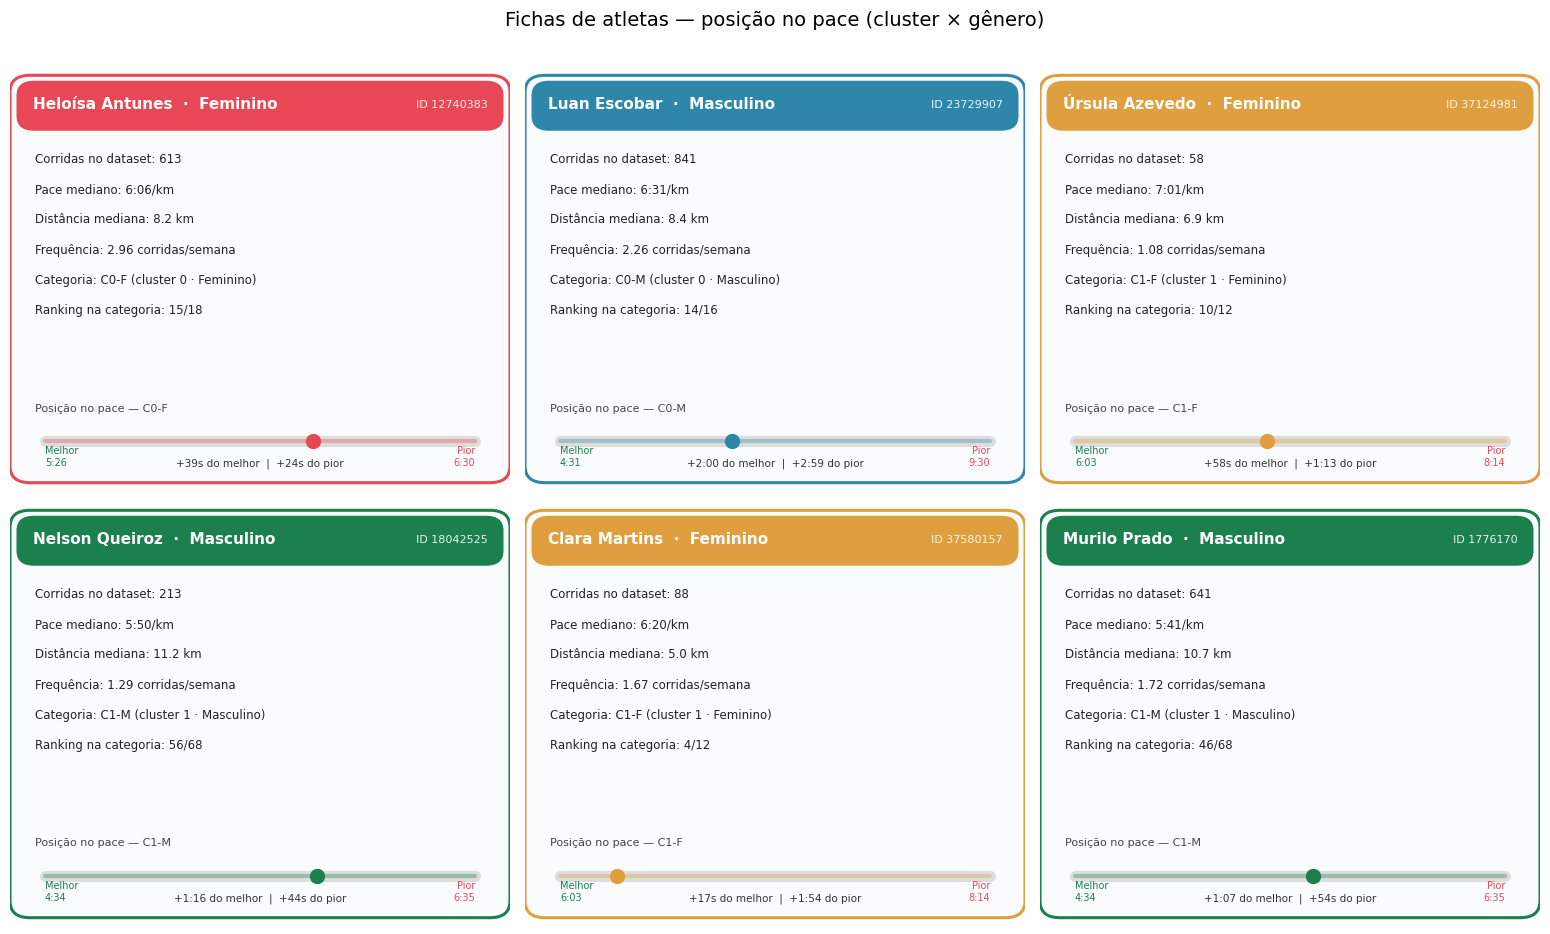

In [147]:
fig = plotar_fichas_atletas(fichas, n=6, seed=42)
plt.show()


### Ficha individual

Troque o `athlete_id` para inspecionar um corredor específico.


Atleta: Júlia Almeida (ID 5035018)
  Categoria: C0-F
  Pace: 5:26/km
  Melhor da categoria: 5:26/km (+0s do melhor)
  Pior da categoria: 6:30/km (+1:03 do pior)
  Ranking: 1/18


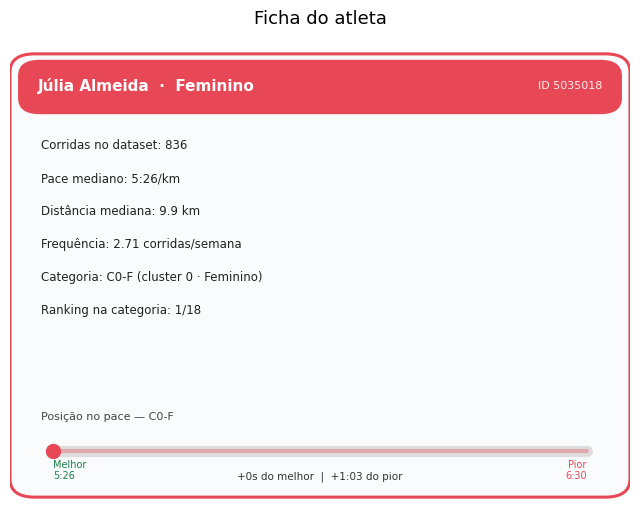

In [148]:
athlete_id = fichas[COL_ATHLETE][0]
linha = fichas.filter(pl.col(COL_ATHLETE) == athlete_id).row(0, named=True)

print(f"Atleta: {linha['nome_ficticio']} (ID {athlete_id})")
print(f"  Categoria: {linha['categoria']}")
print(f"  Pace: {formatar_pace(linha[COL_PACE])}")
print(f"  Melhor da categoria: {formatar_pace(linha['pace_melhor_categoria'])} ({formatar_delta_pace(linha['dist_pace_melhor'])} do melhor)")
print(f"  Pior da categoria: {formatar_pace(linha['pace_pior_categoria'])} ({formatar_delta_pace(linha['dist_pace_pior'])} do pior)")
print(f"  Ranking: {int(linha['ranking_na_categoria'])}/{int(linha['atletas_na_categoria'])}")

fig = plotar_ficha_atleta(fichas, athlete_id)
plt.show()
